# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다.

$$\begin{aligned}
2x_1 + 8x_2 + 2x_3 &= 14\\
x_1 + 6x_2 + 4x_3 &= 15\\
2x_1 + 2x_2 + 3x_3 &= 10
\end{aligned}$$

다루는 내용은

1. **가우스 소거법 직접 구현** + 단계별 첨가행렬 출력
2. rank 로 해의 **존재·유일성 판정**
3. 행렬식과 역행렬, 그리고 행렬식이 0 에 가까울 때의 위험
4. **피벗팅 없는 소거**의 오차 재현과 부분 피벗팅 비교
5. 500x500 에서 `solve` vs `inv @ b` 의 **시간·잔차** 비교

In [18]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 500x500 정도 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# (이 PC 에서는 호출당 약 170 ms) 알고리즘 차이가 통째로 가려진다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[2.0, 8.0, 2.0],
              [1.0, 6.0, 4.0],
              [2.0, 2.0, 3.0]])
b = np.array([14.0, 15.0, 10.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[2. 8. 2.]
 [1. 6. 4.]
 [2. 2. 3.]] 

b = [14. 15. 10.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 작은 수로 나눠서 오차가 증폭되는 것을 막습니다(4-4 에서 확인).

아래는 `src/vectors.py` 에 직접 구현한 소거 함수의 전체 소스입니다.

In [19]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting=True, verbose=False):
    A = np.array(A, dtype=float, copy=True)
    b = np.asarray(b, dtype=float).reshape(-1)

    n = A.shape[0]

    M = np.hstack([
        A,
        b.reshape(-1, 1)
    ])

    steps = [M.copy()]

    if verbose:
        print("[초기] 첨가행렬 [A|b]")
        print(np.array2string(
            M,
            precision=4,
            suppress_small=True
        ))

    for col in range(n):

        if pivoting:
            candidate = col + int(
                np.argmax(np.abs(M[col:, col]))
            )
            if candidate != col:
                M[[col, candidate]] = M[[candidate, col]]
                steps.append(M.copy())

                if verbose:
                    print(
                        f"\n[{col + 1}단계-b] "
                        f"행 {col} <-> 행 {candidate} 교환"
                    )
                    print(np.array2string(
                        M,
                        precision=4,
                  

In [20]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

[초기] 첨가행렬 [A|b]
[[ 2.  8.  2. 14.]
 [ 1.  6.  4. 15.]
 [ 2.  2.  3. 10.]]

[1]단계-a] 0열 아래를 0으로 소거
[[ 2.  8.  2. 14.]
 [ 0.  2.  3.  8.]
 [ 0. -6.  1. -4.]]

[2단계-b] 행 1 <-> 행 2 교환
[[ 2.  8.  2. 14.]
 [ 0. -6.  1. -4.]
 [ 0.  2.  3.  8.]]

[2]단계-a] 1열 아래를 0으로 소거
[[ 2.      8.      2.     14.    ]
 [ 0.     -6.      1.     -4.    ]
 [ 0.      0.      3.3333  6.6667]]

[3]단계-a] 2열 아래를 0으로 소거
[[ 2.      8.      2.     14.    ]
 [ 0.     -6.      1.     -4.    ]
 [ 0.      0.      3.3333  6.6667]]

[후진대입] x = [1. 1. 2.]


In [21]:
print("최종 해 x =", x)
print("정수해 여부 :", np.allclose(x, np.round(x)), "->", np.round(x).astype(int))
print("\nA @ x  =", A @ x)
print("b      =", b)
print("잔차 |A x - b| =", format(np.linalg.norm(A @ x - b), ".3e"))
print("\nnp.linalg.solve =", np.linalg.solve(A, b), "  # 비교 대상")

최종 해 x = [1. 1. 2.]
정수해 여부 : True -> [1 1 2]

A @ x  = [14. 15. 10.]
b      = [14. 15. 10.]
잔차 |A x - b| = 0.000e+00

np.linalg.solve = [1. 1. 2.]   # 비교 대상


In [22]:
# --- 검증 ---
ok = check("해가 (1, 1, 2)", np.allclose(x, [1.0, 1.0, 2.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {})".format(len(steps)), len(steps) >= 4)
ok &= check("마지막 첨가행렬이 상삼각",
            np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (1, 1, 2)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 5)
[PASS] 마지막 첨가행렬이 상삼각

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | **유일해** |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 **무한히 많음** (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | **해 없음** (모순) |

직관: 두 rank 가 같다는 것은 $b$ 가 $A$ 의 **열공간 안에 있다**는 뜻이고,
그래야 $A\mathbf{x}=\mathbf{b}$ 를 만족하는 $\mathbf{x}$ 가 존재합니다.
다르다는 것은 소거 후 `0 = (0이 아닌 수)` 같은 모순 행이 생겼다는 뜻입니다.

In [23]:
Ab = np.hstack([A, b.reshape(-1, 1)])

rA, rAb, n_unknowns = rank(A), rank(Ab), A.shape[1]
print("rank(A)      =", rA)
print("rank([A|b])  =", rAb)
print("미지수 개수 n =", n_unknowns)
print("\n판정 :", "유일해" if rA == rAb == n_unknowns else ("해 없음" if rA < rAb else "해 무한"))
print("np.linalg.matrix_rank :", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab), "  # 검산용")

# 두 rank 가 다른 경우 (해 없음) — b 만 살짝 바꿔서 모순을 만든다
A_dep = np.array([[1.0, 2.0, 3.0],
                  [2.0, 4.0, 6.0],      # 1행의 2배
                  [1.0, 1.0, 1.0]])
b_bad = np.array([1.0, 3.0, 1.0])       # 2행은 2 여야 하는데 3 -> 모순
b_ok = np.array([1.0, 2.0, 1.0])        # 모순 없음 -> 해 무한

for name, bb in [("모순 (해 없음)", b_bad), ("무모순 (해 무한)", b_ok)]:
    ra = rank(A_dep)
    rab = rank(np.hstack([A_dep, bb.reshape(-1, 1)]))
    verdict = "유일해" if ra == rab == 3 else ("해 없음" if ra < rab else "해 무한 (자유변수 {}개)".format(3 - ra))
    print("\n[{}] rank(A)={}, rank([A|b])={} -> {}".format(name, ra, rab, verdict))
    print("  소거 결과 마지막 행 :", row_echelon(np.hstack([A_dep, bb.reshape(-1, 1)]))[0][-1])

rank(A)      = 3
rank([A|b])  = 3
미지수 개수 n = 3

판정 : 유일해
np.linalg.matrix_rank : 3 3   # 검산용

[모순 (해 없음)] rank(A)=2, rank([A|b])=3 -> 해 없음
  소거 결과 마지막 행 : [ 0.   0.   0.  -0.5]

[무모순 (해 무한)] rank(A)=2, rank([A|b])=2 -> 해 무한 (자유변수 1개)
  소거 결과 마지막 행 : [0. 0. 0. 0.]


In [24]:
# --- 검증 ---
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, b_bad.reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, b_ok.reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한가**

역행렬을 여인수 공식으로 쓰면 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 이라
$\det$ 가 작을수록 성분이 폭발합니다. 소거 관점에서는 **아주 작은 피벗으로 나누는 것**과
같아 반올림 오차가 $1/\det$ 배로 증폭됩니다.

다만 **$\det$ 자체는 좋은 판정 기준이 아닙니다.** $\det(cA)=c^n\det(A)$ 라서
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 $10^{-6}$ 배가 되지만
방정식의 난이도는 전혀 변하지 않습니다.
실무 기준은 **조건수(condition number)** $\kappa(A)=\lVert A\rVert\lVert A^{-1}\rVert$ 이고,
입력 오차가 해에서 최대 $\kappa$ 배로 커진다는 의미를 갖습니다.

In [25]:
detA = det(A)
invA = inverse_gauss_jordan(A)

print("det(A) (직접 구현) =", detA)
print("np.linalg.det(A)   =", np.linalg.det(A), "  # 검산용")
print("\nA^-1 (가우스-조던 직접 구현) =\n", invA)
print("\nnp.linalg.inv(A) =\n", np.linalg.inv(A), "  # 검산용")
print("\nA @ A^-1 =\n", A @ invA)
print("\nA^-1 @ b =", invA @ b, " (가우스 소거 해와 같아야 함)")

det(A) (직접 구현) = 40.0
np.linalg.det(A)   = 40.0   # 검산용

A^-1 (가우스-조던 직접 구현) =
 [[ 0.25  -0.5    0.5  ]
 [ 0.125  0.05  -0.15 ]
 [-0.25   0.3    0.1  ]]

np.linalg.inv(A) =
 [[ 0.25  -0.5    0.5  ]
 [ 0.125  0.05  -0.15 ]
 [-0.25   0.3    0.1  ]]   # 검산용

A @ A^-1 =
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

A^-1 @ b = [1. 1. 2.]  (가우스 소거 해와 같아야 함)


In [26]:
# det 가 작아질수록 해가 얼마나 망가지는가
print("{:<14}{:>14}{:>16}{:>16}".format("s (스케일)", "det", "조건수", "해 상대오차"))
print("-" * 62)
scale_rows, dets, conds, errs = [], [], [], []
for s in [1.0, 1e-1, 1e-2, 1e-3]:
    As = A * s                       # 전체 스케일만 바꿈 -> 문제의 난이도는 동일
    xs = np.linalg.solve(As, b * s)
    err = np.linalg.norm(xs - x) / np.linalg.norm(x)
    print("{:<14}{:>14.3e}{:>16.3e}{:>16.3e}".format(s, det(As), np.linalg.cond(As), err))

print("\n-> det 는 10^-9 배까지 작아졌지만 조건수와 오차는 그대로. det 크기는 판정 기준이 아니다.\n")

print("{:<16}{:>14}{:>16}{:>16}".format("eps (진짜 특이에 접근)", "det", "조건수", "해 상대오차"))
print("-" * 64)
for eps in [1e-2, 1e-6, 1e-10, 1e-14]:
    An = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])     # eps -> 0 이면 특이행렬
    bn = np.array([3.0, 6.0 + eps])                   # 참해는 (1, 1)
    xn = np.linalg.solve(An, bn)
    err = np.linalg.norm(xn - np.array([1.0, 1.0]))
    print("{:<16}{:>14.3e}{:>16.3e}{:>16.3e}".format(eps, det(An), np.linalg.cond(An), err))
print("\n-> 이쪽은 조건수가 같이 커지고 해도 실제로 무너진다. 위험한 것은 '작은 det' 가 아니라 '큰 조건수'.")

s (스케일)                  det             조건수          해 상대오차
--------------------------------------------------------------
1.0                4.000e+01       9.115e+00       1.813e-16
0.1                4.000e-02       9.115e+00       4.532e-16
0.01               4.000e-05       9.115e+00       4.054e-16
0.001              4.000e-08       9.115e+00       4.054e-16

-> det 는 10^-9 배까지 작아졌지만 조건수와 오차는 그대로. det 크기는 판정 기준이 아니다.

eps (진짜 특이에 접근)            det             조건수          해 상대오차
----------------------------------------------------------------
0.01                 1.000e-02       2.508e+03       0.000e+00
1e-06                1.000e-06       2.500e+07       0.000e+00
1e-10                1.000e-10       2.500e+11       0.000e+00
1e-14               -0.000e+00       2.098e+15       0.000e+00

-> 이쪽은 조건수가 같이 커지고 해도 실제로 무너진다. 위험한 것은 '작은 det' 가 아니라 '큰 조건수'.


In [27]:
# --- 검증 ---
ok = check("det(A) == 40", np.isclose(detA, 40.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 40
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

피벗팅 없이 소거하면 2행에서 $1/\varepsilon$ 배를 곱해 빼므로,
원래 $O(1)$ 이던 값이 $O(1/\varepsilon)$ 스케일에 **흡수되어 유효숫자가 날아갑니다**.
부분 피벗팅은 두 행을 바꿔 $1$ 을 피벗으로 쓰므로 곱하는 배수가 $\varepsilon$ 이라
이런 손실이 생기지 않습니다.

In [28]:
def solve_eps(eps):
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    rel = lambda v: np.linalg.norm(v - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel(x_no), rel(x_pp)


EPS = 1e-4
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("eps = {}".format(EPS))
print("  참해                :", exact)
print("  피벗팅 없음          :", x_no, "  상대오차 {:.3e}".format(err_no))
print("  부분 피벗팅          :", x_pp, "  상대오차 {:.3e}".format(err_pp))
print("  오차 비율 (없음/있음) : {:.3e} 배".format(err_no / max(err_pp, 1e-300)))

print("\neps 를 줄여 가며 비교")
print("{:<10}{:>18}{:>18}".format("eps", "피벗팅 없음 오차", "부분 피벗팅 오차"))
print("-" * 46)
eps_list = np.logspace(-2, -16, 15)
errs_no, errs_pp = [], []
for e in eps_list:
    _, _, _, en, ep = solve_eps(e)
    errs_no.append(max(en, 1e-18))
    errs_pp.append(max(ep, 1e-18))
    print("{:<10.0e}{:>18.3e}{:>18.3e}".format(e, en, ep))

eps = 0.0001
  참해                : [1.0001 0.9999]
  피벗팅 없음          : [1.0001 0.9999]   상대오차 1.989e-13
  부분 피벗팅          : [1.0001 0.9999]   상대오차 1.570e-16
  오차 비율 (없음/있음) : 1.267e+03 배

eps 를 줄여 가며 비교
eps                피벗팅 없음 오차         부분 피벗팅 오차
----------------------------------------------
1e-02              3.297e-15         1.570e-16
1e-03              1.601e-14         0.000e+00
1e-04              1.989e-13         1.570e-16
1e-05              2.690e-12         0.000e+00
1e-06              3.984e-12         1.570e-16
1e-07              3.563e-10         0.000e+00
1e-08              3.518e-09         1.570e-16
1e-09              2.071e-08         0.000e+00
1e-10              5.844e-08         0.000e+00
1e-11              5.850e-08         0.000e+00
1e-12              1.564e-05         0.000e+00
1e-13              2.199e-04         1.570e-16
1e-14              5.652e-04         0.000e+00
1e-15              5.652e-04         1.570e-16
1e-16              8.630e-01         1.570e-1

/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 48279 (\N{HANGUL SYLLABLE BEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/4207877202.py:12: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.t

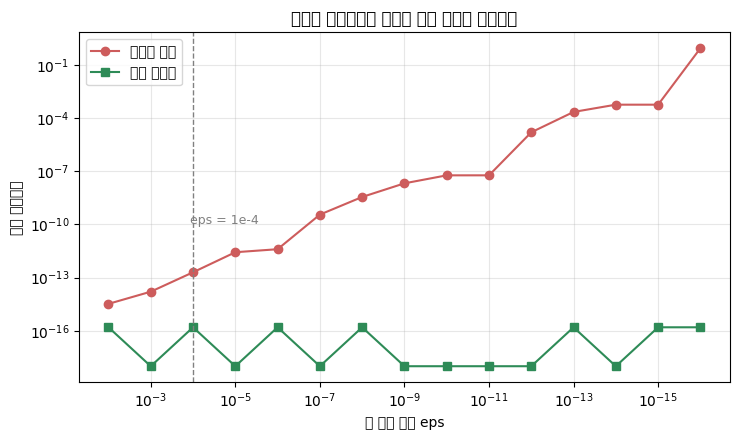

In [29]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = 1e-4", color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [30]:
# --- 검증 ---
ok = check("eps=1e-4 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-4 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 500x500 — `solve` vs `역행렬을 구해서 곱하기`

연산량부터 다릅니다.

| 방법 | 연산량 | 비고 |
|---|---|---|
| `solve(A, b)` (LU 분해 + 전/후진 대입) | $\tfrac{2}{3}n^3$ | 우변 하나면 이걸로 끝 |
| `inv(A) @ b` | $\approx 2n^3$ + 행렬-벡터 곱 | 역행렬 자체가 소거를 $n$ 번 하는 셈 |

정확도도 `solve` 가 낫습니다. 역행렬은 $n^2$ 개 성분을 각각 반올림해 **저장**한 뒤
다시 곱하므로 오차가 한 번 더 섞입니다.
게다가 $A^{-1}$ 은 희소행렬이어도 조밀해져 메모리도 훨씬 많이 씁니다.

In [31]:
N = 500
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다.

    평균 대신 최솟값을 쓰는 이유: OS 스케줄링이나 캐시 미스는 시간을 늘리기만 하므로,
    최솟값이 '방해받지 않았을 때의 순수 연산 시간' 에 가장 가깝다.
    """
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)

res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)

print("행렬 크기 : {0}x{0},  조건수 {1:.3e}".format(N, np.linalg.cond(A_big)))
print("\n{:<26}{:>14}{:>16}".format("방법", "시간 [ms]", "잔차 |Ax-b|"))
print("-" * 56)
print("{:<26}{:>14.3f}{:>16.3e}".format("np.linalg.solve", t_solve * 1e3, res_solve))
print("{:<26}{:>14.3f}{:>16.3e}".format("np.linalg.inv(A) @ b", t_inv * 1e3, res_inv))
print("\n속도 비율 : inv 방식이 {:.2f} 배 느림".format(t_inv / t_solve))
print("잔차 비율 : inv / solve = {:.2f}".format(res_inv / res_solve))
print("메모리     : solve 는 b 하나(4 KB), inv 는 {} x {} 행렬({:.1f} MB) 을 따로 저장".format(
    N, N, N * N * 8 / 1e6))

# 조건수가 좋을 때(위 A_big 은 cond ~ 700)는 잔차 차이가 거의 없다.
# 정확도 차이는 조건수가 나빠질수록 벌어지므로, 조건수를 지정해 다시 비교한다.


def make_conditioned(n, cond, gen):
    """지정한 조건수를 갖는 n x n 행렬을 SVD 형태로 조립한다."""
    Q1, _ = np.linalg.qr(gen.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(gen.standard_normal((n, n)))
    sv = np.logspace(0, -np.log10(cond), n)
    return (Q1 * sv) @ Q2.T


print("\n\n조건수별 해의 상대오차 (200x200, 참해 = 전부 1)")
print("{:<14}{:>18}{:>18}".format("조건수", "solve 오차", "inv @ b 오차"))
print("-" * 50)
cond_list, err_solve_list, err_inv_list = [], [], []
x_true_big = np.ones(200)
for c in [1e2, 1e6, 1e10, 1e13]:
    Ac = make_conditioned(200, c, rng)
    bc = Ac @ x_true_big
    e_s = np.linalg.norm(np.linalg.solve(Ac, bc) - x_true_big) / np.linalg.norm(x_true_big)
    e_i = np.linalg.norm(np.linalg.inv(Ac) @ bc - x_true_big) / np.linalg.norm(x_true_big)
    cond_list.append(c)
    err_solve_list.append(e_s)
    err_inv_list.append(e_i)
    print("{:<14.0e}{:>18.3e}{:>18.3e}".format(c, e_s, e_i))
print("\n-> 조건수가 나빠질수록 inv 방식의 오차가 더 빨리 커진다.")
print("   역행렬을 n^2 개 성분으로 반올림해 저장했다가 다시 곱하는 만큼 반올림이 한 단계 더 들어가기 때문이다.")

행렬 크기 : 500x500,  조건수 6.746e+02

방법                               시간 [ms]       잔차 |Ax-b|
--------------------------------------------------------
np.linalg.solve                    1.992       2.865e-12
np.linalg.inv(A) @ b               6.639       3.772e-12

속도 비율 : inv 방식이 3.33 배 느림
잔차 비율 : inv / solve = 1.32
메모리     : solve 는 b 하나(4 KB), inv 는 500 x 500 행렬(2.0 MB) 을 따로 저장


조건수별 해의 상대오차 (200x200, 참해 = 전부 1)
조건수                     solve 오차        inv @ b 오차
--------------------------------------------------
1e+02                  1.033e-14         5.086e-14
1e+06                  2.697e-11         2.151e-10
1e+10                  1.184e-07         1.169e-06
1e+13                  6.477e-05         2.003e-03

-> 조건수가 나빠질수록 inv 방식의 오차가 더 빨리 커진다.
   역행렬을 n^2 개 성분으로 반올림해 저장했다가 다시 곱하는 만큼 반올림이 한 단계 더 들어가기 때문이다.


/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_12582/748331136.py:19: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.ti

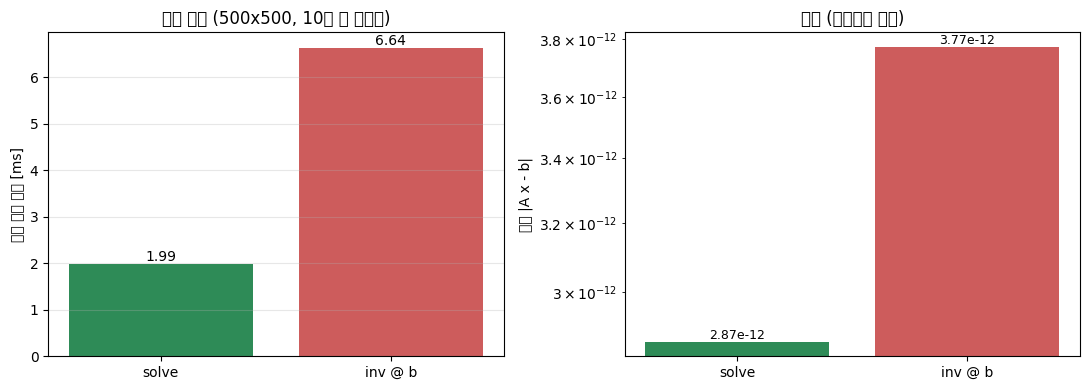

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("평균 실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

**결론 — 실무에서는 `solve` 를 쓴다.**

- **속도**: `inv` 는 같은 소거를 $n$ 개의 우변에 대해 반복하는 것이라 상수배로 느립니다.
- **정확도**: 역행렬을 한 번 저장했다 다시 곱하는 만큼 반올림이 한 단계 더 들어갑니다.
- **메모리**: $A^{-1}$ 은 $n^2$ 개를 조밀하게 저장합니다. 희소행렬이면 손해가 더 큽니다.
- 우변이 여러 개면 `inv` 대신 **LU 분해를 한 번 하고 재사용**(`scipy.linalg.lu_factor`/`lu_solve`)합니다.
- 역행렬을 **명시적으로 봐야 할 때**(공분산 전파, 감도 해석 등)만 `inv` 를 씁니다.
- 이 과제의 `inv_T`(문제 5)는 예외입니다. 소거가 아니라 **전치**로 끝나는 닫힌 공식이라 오히려 더 빠릅니다.

In [33]:
# --- 검증 ---
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
print(res_solve,res_inv*1.5)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
2.8651759124191433e-12 5.658371954962968e-12
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [34]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀의 [초기]/[1~3단계] 출력 참조
   최종 해: x = {sol}  (정수해, A @ x = b 확인)

2. rank A: {ra} / rank 첨가행렬: {rab}  (미지수 3개)
   - 판정: rank(A) = rank([A|b]) = n = 3 이므로 해가 존재하고 유일하다.
   - 두 rank 가 같으면 b 가 A 의 열공간 안에 있어 해가 존재하고,
     다르면 소거 후 '0 = 0이 아닌 수' 모순 행이 생겨 해가 없다.
     같지만 n 보다 작으면 자유변수가 생겨 해가 무한히 많다.

3. 행렬식: {dt:.1f}
   역행렬:
{inv}
   - det 가 0 에 가까우면 A^-1 = adj(A)/det(A) 의 성분이 폭발하고,
     소거 관점에서는 아주 작은 피벗으로 나누는 셈이라 반올림 오차가 증폭된다.
     단 det 크기 자체는 스케일에 따라 변하므로 실제 판정 기준은 조건수다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-4):
   {e_no:.3e} / {e_pp:.3e}   -> {ratio:.2e} 배 차이
   (eps 를 1e-16 까지 줄이면 피벗팅 없는 쪽은 {worst:.2e} 까지 무너지고, 피벗팅 쪽은 그대로)

5. solve vs 역행렬 곱셈 ({n}x{n}, 워밍업 후 {rep}회 중 최솟값, BLAS 1스레드 고정)
   - 시간 : {ts:.3f} ms / {ti:.3f} ms   (inv 방식이 {tr:.2f} 배 느림)
   - 잔차 : {rs:.3e} / {ri:.3e}   (조건수 {cnd:.0f} 로 양호해 잔차는 사실상 동급)
   - 조건수를 키우면 정확도 차이가 드러난다 (200x200, 참해 = 전부 1)
       cond 1e10 : solve {es10:.3e} / inv {ei10:.3e}
       cond 1e13 : solve {es13:.3e} / inv {ei13:.3e}
   - 결론 : solve 를 쓴다. 연산량이 (2/3)n^3 vs 약 2n^3 이라 {tr:.1f} 배 느리고,
     역행렬은 n^2 개 성분을 반올림해 저장했다 다시 곱하므로 조건수가 나쁠수록 오차가 커지며,
     메모리도 {mem:.1f} MB 를 더 쓴다. 우변이 여러 개면 inv 대신 LU 분해를 한 번 하고 재사용한다.
""".format(
    sol=np.round(x, 10),
    ra=rA, rab=rAb, dt=detA,
    inv="\n".join("     " + line for line in np.array2string(invA, precision=6).splitlines()),
    e_no=err_no, e_pp=err_pp, ratio=err_no / max(err_pp, 1e-300),
    worst=errs_no[-1],
    n=N, rep=REPEAT,
    ts=t_solve * 1e3, ti=t_inv * 1e3, tr=t_inv / t_solve,
    rs=res_solve, ri=res_inv, cnd=np.linalg.cond(A_big),
    es10=err_solve_list[2], ei10=err_inv_list[2],
    es13=err_solve_list[3], ei13=err_inv_list[3],
    mem=N * N * 8 / 1e6,
)
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀의 [초기]/[1~3단계] 출력 참조
   최종 해: x = [1. 1. 2.]  (정수해, A @ x = b 확인)

2. rank A: 3 / rank 첨가행렬: 3  (미지수 3개)
   - 판정: rank(A) = rank([A|b]) = n = 3 이므로 해가 존재하고 유일하다.
   - 두 rank 가 같으면 b 가 A 의 열공간 안에 있어 해가 존재하고,
     다르면 소거 후 '0 = 0이 아닌 수' 모순 행이 생겨 해가 없다.
     같지만 n 보다 작으면 자유변수가 생겨 해가 무한히 많다.

3. 행렬식: 40.0
   역행렬:
     [[ 0.25  -0.5    0.5  ]
      [ 0.125  0.05  -0.15 ]
      [-0.25   0.3    0.1  ]]
   - det 가 0 에 가까우면 A^-1 = adj(A)/det(A) 의 성분이 폭발하고,
     소거 관점에서는 아주 작은 피벗으로 나누는 셈이라 반올림 오차가 증폭된다.
     단 det 크기 자체는 스케일에 따라 변하므로 실제 판정 기준은 조건수다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-4):
   1.989e-13 / 1.570e-16   -> 1.27e+03 배 차이
   (eps 를 1e-16 까지 줄이면 피벗팅 없는 쪽은 8.63e-01 까지 무너지고, 피벗팅 쪽은 그대로)

5. solve vs 역행렬 곱셈 (500x500, 워밍업 후 10회 중 최솟값, BLAS 1스레드 고정)
   - 시간 : 1.992 ms / 6.639 ms   (inv 방식이 3.33 배 느림)
   - 잔차 : 2.865e-12 / 3.772e-12   (조건수 675 로 양호해 잔차는 사실상 동급)
   - 조건수를 키우면 정확도 차이가 드러난다 (200x200, 참해 = 전부 1)
       cond 1e10 : solve 1.184e-07 / inv 1.169e-06
      